In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hotel-booking-demand/hotel_bookings.csv


**Hotel booking analisis**

## Este proyecto corresponde a un caso ficticio de análisis de datos desarrollado con fines académicos y de portafolio, utilizando un dataset público de Kaggle. Las conclusiones y recomendaciones presentadas no corresponden a un cliente real.##

In [2]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report, roc_auc_score
)

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [3]:
# Cargar dataset
df_hotel = pd.read_csv("/kaggle/input/hotel-booking-demand/hotel_bookings.csv")


In [4]:
# resumen de los datos
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# datos nulos en todas las columnas, al parecer existen algunas cuantas en country,agent,company,
df_hotel.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
# existen 31994 datos duplicados en todo el dataset
df_hotel.duplicated().sum()

np.int64(31994)

# Dado que el dataset no cuenta con identificadores únicos de reserva o cliente, no es posible confirmar si los registros duplicados corresponden a entradas repetidas o a reservas distintas con patrones idénticos. Sin embargo, al tratarse de observaciones completamente iguales, se opta por su eliminación para evitar la sobre-representación de un mismo patrón en los modelos predictivos.

In [7]:
# Revisamos los outliers del dataset, por medio de sus descriptivos, grafico de box plot y el IQR.
df_hotel["adr"].describe()


count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

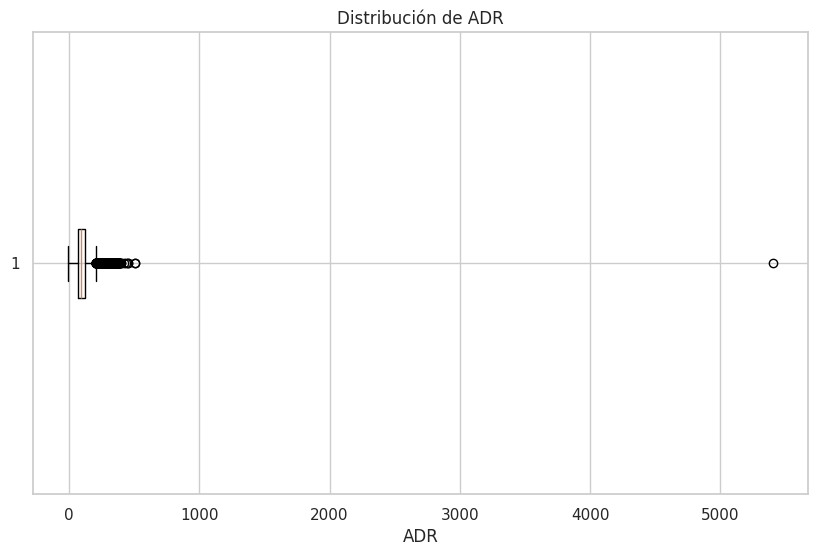

In [8]:
plt.boxplot(df_hotel["adr"], vert=False)
plt.title("Distribución de ADR")
plt.xlabel("ADR")
plt.show()


In [9]:
Q1 = df_hotel["adr"].quantile(0.25)
Q3 = df_hotel["adr"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_adr = df_hotel[
    (df_hotel["adr"] < limite_inferior) | 
    (df_hotel["adr"] > limite_superior)
]

outliers_adr.shape


(3793, 32)

In [10]:
# 1) Eliminar filas duplicadas (duplicados exactos en todas las columnas)
print("Filas antes:", df_hotel.shape[0])
duplicados = df_hotel.duplicated().sum()
print("Duplicados detectados:", duplicados)

df_hotel = df_hotel.drop_duplicates()

print("Filas después de eliminar duplicados:", df_hotel.shape[0])


Filas antes: 119390
Duplicados detectados: 31994
Filas después de eliminar duplicados: 87396


In [11]:
# 2) Imputar valores nulos con criterio de negocio
# - Numéricas: 0
# - Categóricas: "Unknown"
df_hotel["children"] = df_hotel["children"].fillna(0)
df_hotel["agent"]    = df_hotel["agent"].fillna(0)
df_hotel["company"]  = df_hotel["company"].fillna(0)
df_hotel["country"]  = df_hotel["country"].fillna("Unknown")

print("\nNulos después de imputación (solo si queda algo):")
print(df_hotel[["children","agent","company","country"]].isnull().sum())



Nulos después de imputación (solo si queda algo):
children    0
agent       0
company     0
country     0
dtype: int64


In [12]:
# 3) Tratar outliers en ADR
# 3a) Eliminar valores negativos (no tienen sentido para precio)
df_hotel = df_hotel[df_hotel["adr"] >= 0]

# 3b) Capping (tope) al percentil 99 para reducir el impacto de extremos
p99 = df_hotel["adr"].quantile(0.99)
df_hotel["adr"] = df_hotel["adr"].clip(upper=p99)

print("\nResumen ADR después de limpiar:")
print(df_hotel["adr"].describe())
print("\nPercentil 99 usado como tope:", p99)


Resumen ADR después de limpiar:
count    87395.000000
mean       105.955756
std         50.843868
min          0.000000
25%         72.000000
50%         98.100000
75%        134.000000
max        261.406000
Name: adr, dtype: float64

Percentil 99 usado como tope: 261.4059999999997


# Tras el proceso de limpieza, el dataset quedó conformado por registros únicos, sin valores nulos relevantes y con una distribución de precios más estable, permitiendo un análisis y modelado más robusto.

In [13]:
# analisis eda / Tasa de cancelacion total

tasa_cancelacion = df_hotel["is_canceled"].mean()*100
tasa_cancelacion


np.float64(27.49013101436009)

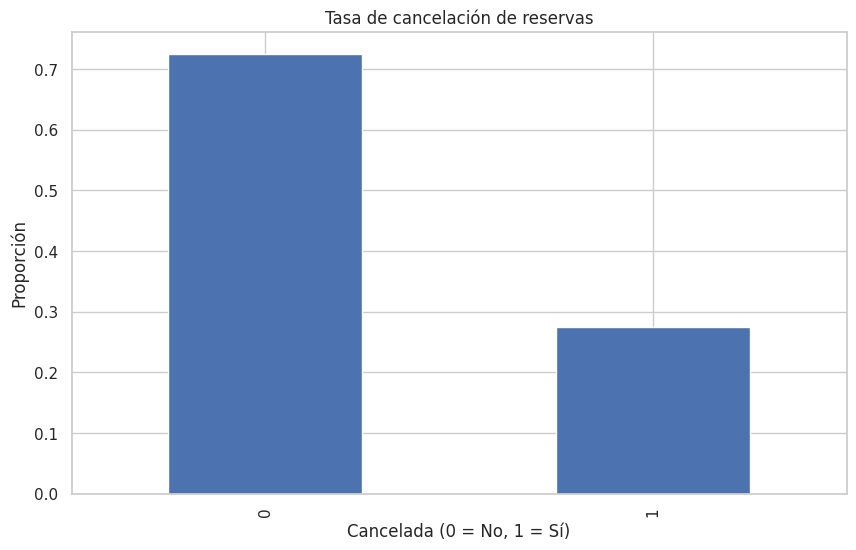

In [14]:
df_hotel["is_canceled"].value_counts(normalize=True).plot(
    kind="bar",
    title="Tasa de cancelación de reservas",
    ylabel="Proporción",
    xlabel="Cancelada (0 = No, 1 = Sí)"
)
plt.show()


# El análisis muestra que aproximadamente el 27,5% de las reservas son canceladas, lo que representa un riesgo significativo para los ingresos del hotel. Este nivel de cancelación justifica el desarrollo de un modelo de regresión logística para anticipar reservas con alta probabilidad de cancelación y apoyar la toma de decisiones preventivas.

In [15]:
# cancelacion por tipo de cliente 

cancelacion_por_cliente = (
    df_hotel
    .groupby("customer_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

cancelacion_por_cliente


customer_type
Transient          30.105854
Contract           16.310927
Transient-Party    15.239638
Group               9.926471
Name: is_canceled, dtype: float64

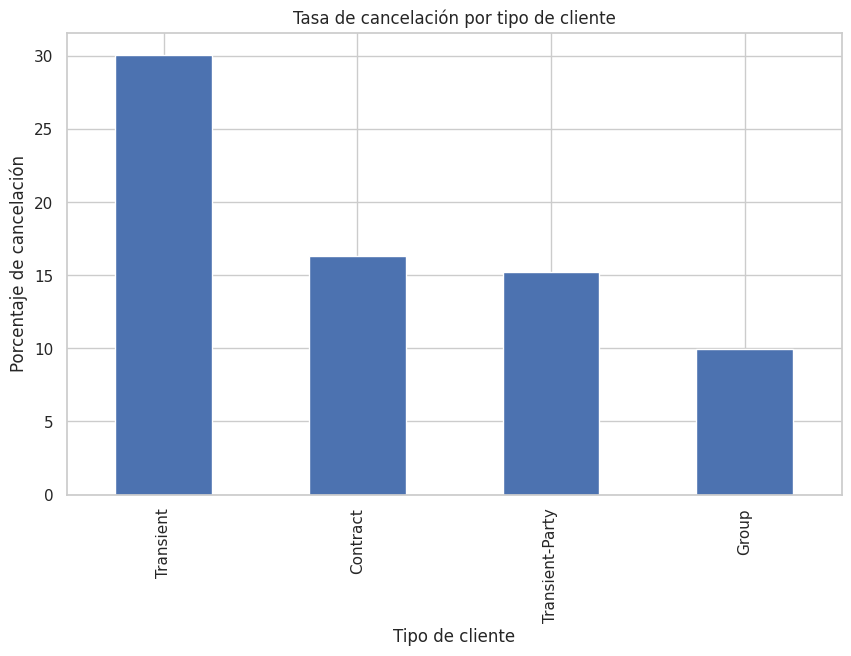

In [16]:
cancelacion_por_cliente.plot(
    kind="bar",
    title="Tasa de cancelación por tipo de cliente",
    ylabel="Porcentaje de cancelación",
    xlabel="Tipo de cliente"
)
plt.show()


# El análisis evidencia que la tasa de cancelación varía significativamente según el tipo de cliente. Los clientes transitorios presentan la mayor probabilidad de cancelación, mientras que los clientes grupales y contractuales muestran un comportamiento considerablemente más estable, lo que sugiere la necesidad de políticas diferenciadas según el segmento.

In [17]:
# cancelacion vs leadtime

df_hotel.groupby("is_canceled")["lead_time"].mean()


is_canceled
0     70.097617
1    105.719251
Name: lead_time, dtype: float64

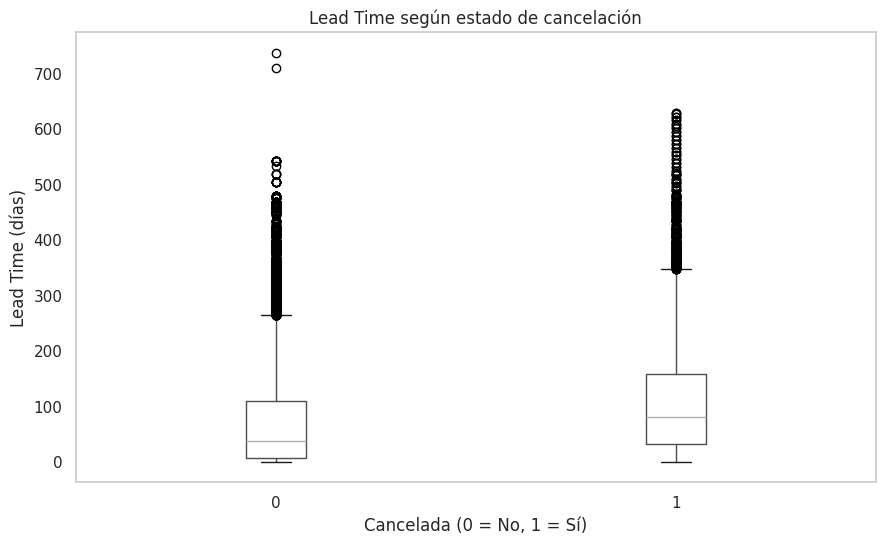

In [18]:
df_hotel.boxplot(
    column="lead_time",
    by="is_canceled",
    grid=False
)
plt.title("Lead Time según estado de cancelación")
plt.suptitle("")
plt.xlabel("Cancelada (0 = No, 1 = Sí)")
plt.ylabel("Lead Time (días)")
plt.show()


*El análisis confirma que las reservas con mayor lead time presentan una mayor probabilidad de cancelación. Si bien existen valores extremos de anticipación, estos son consistentes con reservas de tipo contractual o grupal y no se consideran errores de registro.*


In [19]:
adr_por_mes = (
    df_hotel
    .groupby("arrival_date_month")["adr"]
    .mean()
    .sort_values(ascending=False)
)

adr_por_mes


arrival_date_month
August       149.398047
July         134.903311
June         119.641266
September    112.027644
May          111.040323
April        103.546147
October       90.135326
December      81.063484
March         80.931424
February      74.682986
November      72.754460
January       70.045885
Name: adr, dtype: float64

In [20]:
adr_mes_hotel = (
    df_hotel
    .groupby(["arrival_date_month", "hotel"])["adr"]
    .mean()
    .reset_index()
    
)

adr_mes_hotel.head()


,arrival_date_month,hotel,adr
0,April,City Hotel,117.054513
1,April,Resort Hotel,79.280766
2,August,City Hotel,124.715294
3,August,Resort Hotel,184.263889
4,December,City Hotel,92.558153


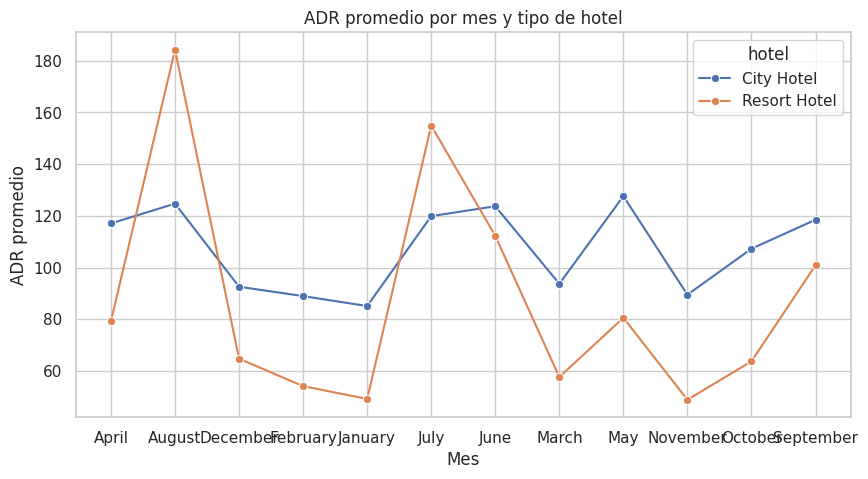

In [21]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(
    data=adr_mes_hotel,
    x="arrival_date_month",
    y="adr",
    hue="hotel",
    marker="o"
)
plt.title("ADR promedio por mes y tipo de hotel")
plt.xlabel("Mes")
plt.ylabel("ADR promedio")
plt.show()


**El análisis del ADR evidencia una fuerte estacionalidad en los precios, con incrementos significativos durante los meses de verano. Sin embargo, este efecto no impacta de igual forma a todos los hoteles: los Resort Hotels concentran los mayores aumentos de precio en temporada alta, mientras que los City Hotels mantienen un comportamiento más estable a lo largo del año. Esto indica que la demanda estacional impulsa principalmente a los resorts, por lo que una estrategia de pricing diferenciada por tipo de hotel y temporada resulta clave para maximizar ingresos.**

In [22]:
# Regresion logistica
Y = df_hotel["is_canceled"]  # Variable objetivo

features = [
    "lead_time",
    "hotel",
    "customer_type",
    "deposit_type",
    "previous_cancellations",
    "booking_changes",
    "total_of_special_requests",
    "adr"
]
X = df_hotel[features]

In [23]:
# Encoding variables categoricas
X_encoded = pd.get_dummies(
    X,
    columns=["hotel", "customer_type", "deposit_type"],
    drop_first=True
)


In [24]:
# entrenamiento del modelo
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_encoded, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


In [25]:
# escala el nivel de las variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [26]:
#Entremaniento del modelo
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train_scaled, Y_train)


LogisticRegression(max_iter=1000)

In [27]:
#Predicciones
y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]


In [28]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report

accuracy = accuracy_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
roc_auc = roc_auc_score(Y_test, y_proba)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)
print("\nReporte de clasificación:\n", classification_report(Y_test, y_pred))


Accuracy: 0.7509010812975571
Recall: 0.2024973985431842
ROC-AUC: 0.7148683047894229

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.76      0.96      0.85     12674
           1       0.65      0.20      0.31      4805

    accuracy                           0.75     17479
   macro avg       0.71      0.58      0.58     17479
weighted avg       0.73      0.75      0.70     17479



In [29]:
import pandas as pd

coeficientes = pd.Series(
    modelo.coef_[0],
    index=X_train.columns
).sort_values()

coeficientes


total_of_special_requests       -0.398928
booking_changes                 -0.309162
hotel_Resort Hotel              -0.139167
customer_type_Transient-Party   -0.082543
customer_type_Group             -0.016276
deposit_type_Refundable          0.023462
previous_cancellations           0.183669
customer_type_Transient          0.337599
adr                              0.340367
deposit_type_Non Refund          0.345579
lead_time                        0.497721
dtype: float64


**El modelo de regresión logística permitió identificar los principales factores asociados a la cancelación de reservas, destacando la anticipación de la reserva (lead time), el precio promedio diario (ADR), el tipo de cliente y el historial de cancelaciones como variables de mayor influencia.Si bien el modelo presenta una capacidad adecuada de discriminación entre reservas canceladas y no canceladas, su configuración inicial resulta conservadora, priorizando la correcta clasificación de las reservas no canceladas. Para un uso operativo en el negocio, se recomienda ajustar el umbral de decisión o balancear las clases con el fin de aumentar la detección temprana de cancelaciones, incluso a costa de una ligera disminución en la exactitud general.En conjunto, el modelo constituye una herramienta útil para apoyar la toma de decisiones preventivas, permitiendo al hotel anticipar reservas de alto riesgo y aplicar estrategias de mitigación que reduzcan el impacto económico de las cancelaciones.**


In [30]:
#Regresion linial 
features_num = [
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults",
    "children",
    "babies",
    "total_of_special_requests",
    "booking_changes"
]

X = df_hotel[features_num]
y = df_hotel["adr"]





In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1) Entrenar
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

# 2) Predecir
y_pred = lin_model.predict(X_test_scaled)

# 3) Evaluar
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)


R²: 0.20318951026494203
RMSE: 45.71891688562681


In [33]:
coef = pd.Series(lin_model.coef_, index=features_num).sort_values()
coef

lead_time                    -1.465960
booking_changes              -0.172267
stays_in_weekend_nights      -0.096385
babies                        0.259952
stays_in_week_nights          1.537093
total_of_special_requests     5.534972
adults                       11.996250
children                     16.816026
dtype: float64

**“El modelo de regresión lineal permitió identificar los factores que influyen en el ADR, destacando el perfil del cliente y el tamaño del grupo como los principales determinantes del precio. Sin embargo, su capacidad predictiva es limitada, por lo que el modelo se utiliza con fines explicativos y de apoyo a decisiones estratégicas, más que para la predicción exacta de precios.”**